In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")

In [3]:
DATA_PATH = Path(
    "../data/final/germany/2020/germany_2020_full_dataset.csv"
)


df = pd.read_csv(
    DATA_PATH,
    index_col="datetime",
    parse_dates=True
)


df.head()

,price_eur_mwh,load_mw,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,...,day_of_week,month,quarter,weekend,season,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,precipitation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,41.88,43968.4775,4824.6925,9316.9650,6053.3050,1961.8225,453.7350,31.7325,623.9150,1329.9625,...,2,1,1,0,Winter,2.2,12.0,0.0,4,0.0
2020-01-01 01:00:00,38.60,43046.6850,4801.3625,9419.0675,5681.1275,1825.3025,453.7475,31.8300,669.5575,1324.1700,...,2,1,1,0,Winter,1.6,11.4,0.0,2,0.0
2020-01-01 02:00:00,36.55,41894.8125,4798.6200,9425.6025,5493.5650,1797.2450,454.1350,31.7825,2365.8325,1319.1300,...,2,1,1,0,Winter,2.1,10.3,0.0,3,0.0
2020-01-01 03:00:00,32.32,40701.6450,4794.6875,9497.3350,5512.7200,1899.2875,453.7275,31.4400,2454.5475,1311.7875,...,2,1,1,0,Winter,1.8,11.2,0.0,12,0.0
2020-01-01 04:00:00,30.85,40681.4025,4796.4000,9549.8575,5415.3625,1922.8025,453.7300,31.5625,2269.9450,1307.1850,...,2,1,1,0,Winter,1.2,10.1,0.0,3,0.0


In [4]:
print("="*60)
print("Dataset Overview")
print("="*60)

print()

print("Shape:")
print(df.shape)

print()

print("Columns:")
print(df.columns.tolist())

print()

print("Missing values:")
print(df.isna().sum().sum())

print()

df.info()

Dataset Overview

Shape:
(8783, 32)

Columns:
['price_eur_mwh', 'load_mw', 'Biomass', 'Fossil Brown coal/Lignite', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Geothermal', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear', 'Other', 'Other renewable', 'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore', 'renewable_generation', 'fossil_generation', 'residual_load', 'hour', 'day_of_week', 'month', 'quarter', 'weekend', 'season', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'precipitation']

Missing values:
0

<class 'pandas.DataFrame'>
DatetimeIndex: 8783 entries, 2020-01-01 00:00:00 to 2020-12-31 23:00:00
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price_eur_mwh                    8783 non-null   float64
 1   load_mw                          8783 non-null   float64
 2   Biomass                    

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_eur_mwh,8783.0,30.474174,17.498840,-83.9400,21.76000,30.9900,40.25000,200.0400
load_mw,8783.0,55818.784971,10037.503638,33428.2725,47700.93125,55683.1775,63297.72750,79361.6775
Biomass,8783.0,4580.888579,219.551790,3975.0125,4418.16250,4592.1375,4750.15875,5098.7200
Fossil Brown coal/Lignite,8783.0,9492.161618,3812.852559,2886.1925,6062.37875,9855.0875,12552.66875,16913.0700
Fossil Gas,8783.0,7723.776116,2997.003297,2160.0175,5437.38125,7701.4075,9538.38625,17346.2450
Fossil Hard coal,8783.0,3970.227807,3162.281367,738.1900,1877.32375,2660.3600,4856.93250,16393.4325
Fossil Oil,8783.0,422.711887,47.994670,338.5150,393.86375,417.5850,441.39875,933.3150
Geothermal,8783.0,22.413615,5.327648,5.9025,18.21500,22.6850,27.03000,33.2375
Hydro Pumped Storage,8783.0,1231.450821,790.285636,0.6850,565.98750,1083.9250,1864.89250,4946.8400
Hydro Run-of-river and poundage,8783.0,1643.110645,254.300466,1076.6825,1415.81250,1671.3850,1832.39875,2255.3525


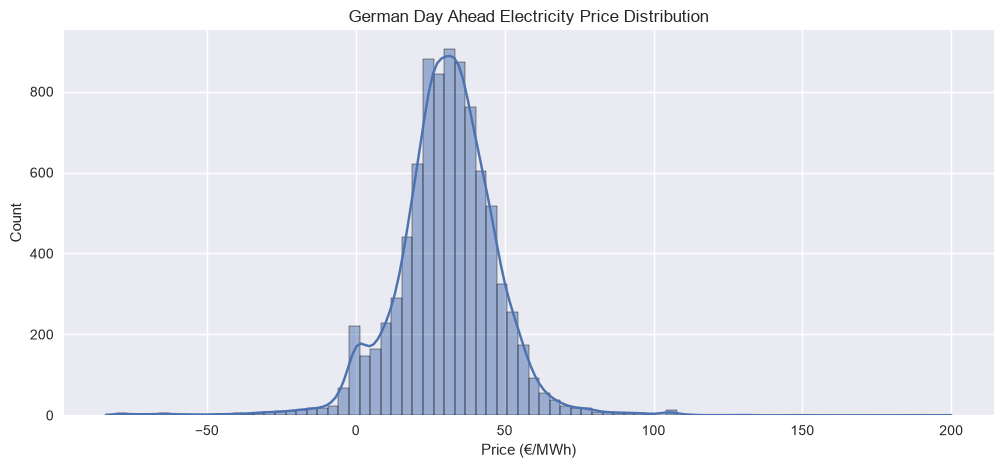

In [6]:
plt.figure(figsize=(12,5))

sns.histplot(
    df["price_eur_mwh"],
    bins=80,
    kde=True
)

plt.title(
    "German Day Ahead Electricity Price Distribution"
)

plt.xlabel(
    "Price (€/MWh)"
)

plt.show()

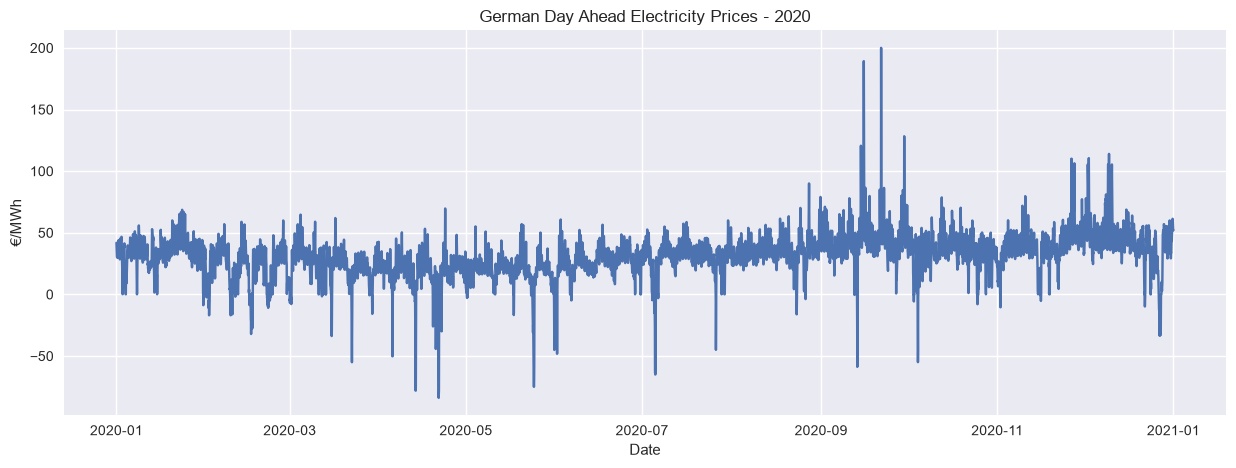

In [7]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["price_eur_mwh"]
)

plt.title(
    "German Day Ahead Electricity Prices - 2020"
)

plt.ylabel(
    "€/MWh"
)

plt.xlabel(
    "Date"
)

plt.show()

In [8]:
price_stats = pd.DataFrame({
    "Mean": [df.price_eur_mwh.mean()],
    "Median": [df.price_eur_mwh.median()],
    "Std": [df.price_eur_mwh.std()],
    "Min": [df.price_eur_mwh.min()],
    "Max": [df.price_eur_mwh.max()]
})


price_stats

,Mean,Median,Std,Min,Max
0,30.474174,30.99,17.49884,-83.94,200.04


In [9]:
negative_prices = df[
    df["price_eur_mwh"] < 0
]


print(
    "Negative price hours:",
    len(negative_prices)
)


negative_prices.head()

Negative price hours: 298


,price_eur_mwh,load_mw,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,...,day_of_week,month,quarter,weekend,season,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,precipitation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-31 00:00:00,-0.04,56462.1525,4738.7150,4978.0775,3501.6400,2169.1000,446.0900,28.1750,1864.6400,1377.2125,...,4,1,1,0,Winter,5.4,20.4,0.0,100,0.3
2020-01-31 02:00:00,-8.77,53333.5750,4703.7025,4724.5875,3383.4000,2197.8300,446.5475,27.1125,2390.8950,1374.4850,...,4,1,1,0,Winter,6.4,25.2,0.0,100,0.1
2020-01-31 03:00:00,-3.89,53603.3375,4682.4925,4730.6100,3333.7725,2199.1925,446.5475,26.7400,2403.2975,1377.8925,...,4,1,1,0,Winter,7.3,26.9,0.0,100,0.0
2020-02-01 02:00:00,-0.70,49741.9200,4747.9875,3964.1425,3630.5575,1998.1200,453.7450,27.7800,2474.7875,1376.8250,...,5,2,1,1,Winter,10.7,17.3,0.0,100,0.3
2020-02-01 03:00:00,-1.94,49538.5050,4750.4400,3950.3200,3599.3025,2003.4150,453.7400,28.2125,2389.9450,1379.9075,...,5,2,1,1,Winter,10.8,16.2,0.0,100,0.0


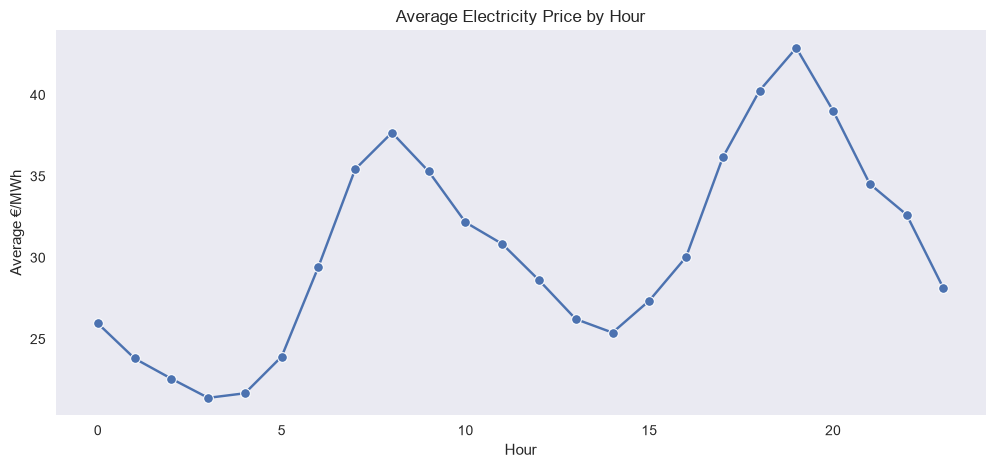

In [10]:
hourly_price = (
    df
    .groupby("hour")["price_eur_mwh"]
    .mean()
)


plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_price.index,
    y=hourly_price.values,
    marker="o"
)


plt.title(
    "Average Electricity Price by Hour"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Average €/MWh"
)

plt.grid()

plt.show()

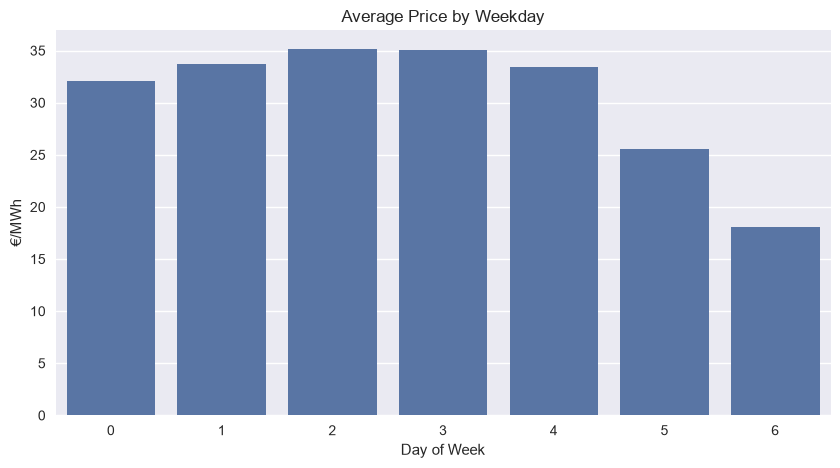

In [11]:
weekday_price = (
    df
    .groupby("day_of_week")
    ["price_eur_mwh"]
    .mean()
)


plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_price.index,
    y=weekday_price.values
)


plt.title(
    "Average Price by Weekday"
)

plt.xlabel(
    "Day of Week"
)

plt.ylabel(
    "€/MWh"
)

plt.show()

In [12]:
weekend_price = (
    df
    .groupby("weekend")
    ["price_eur_mwh"]
    .mean()
)


weekend_price

weekend
0    33.896318
1    21.849547
Name: price_eur_mwh, dtype: float64

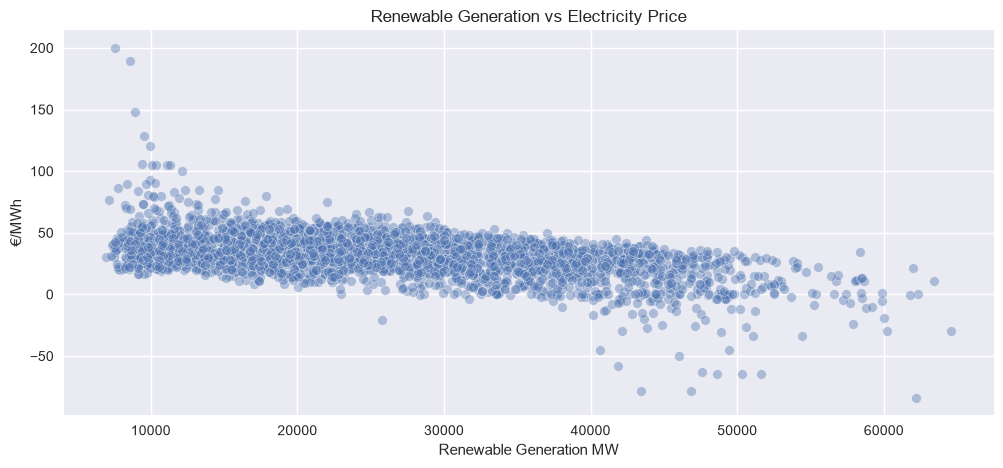

In [13]:
plt.figure(figsize=(12,5))

sns.scatterplot(
    data=df.sample(3000),
    x="renewable_generation",
    y="price_eur_mwh",
    alpha=0.4
)


plt.title(
    "Renewable Generation vs Electricity Price"
)

plt.xlabel(
    "Renewable Generation MW"
)

plt.ylabel(
    "€/MWh"
)

plt.show()

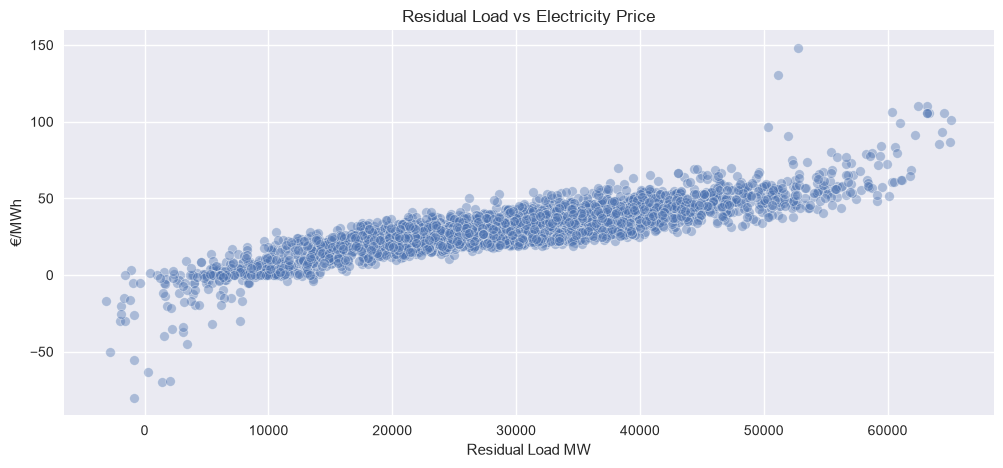

In [14]:
plt.figure(figsize=(12,5))

sns.scatterplot(
    data=df.sample(3000),
    x="residual_load",
    y="price_eur_mwh",
    alpha=0.4
)


plt.title(
    "Residual Load vs Electricity Price"
)

plt.xlabel(
    "Residual Load MW"
)

plt.ylabel(
    "€/MWh"
)

plt.show()

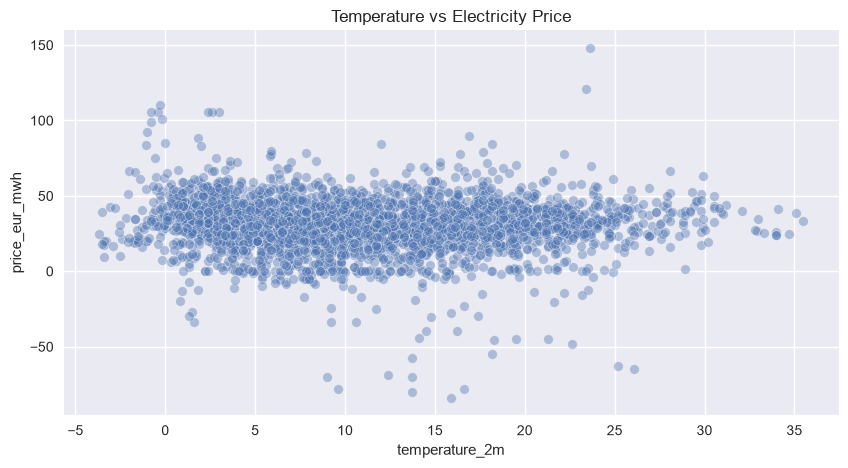

In [15]:
plt.figure(figsize=(10,5))


sns.scatterplot(
    data=df.sample(3000),
    x="temperature_2m",
    y="price_eur_mwh",
    alpha=0.4
)


plt.title(
    "Temperature vs Electricity Price"
)


plt.show()

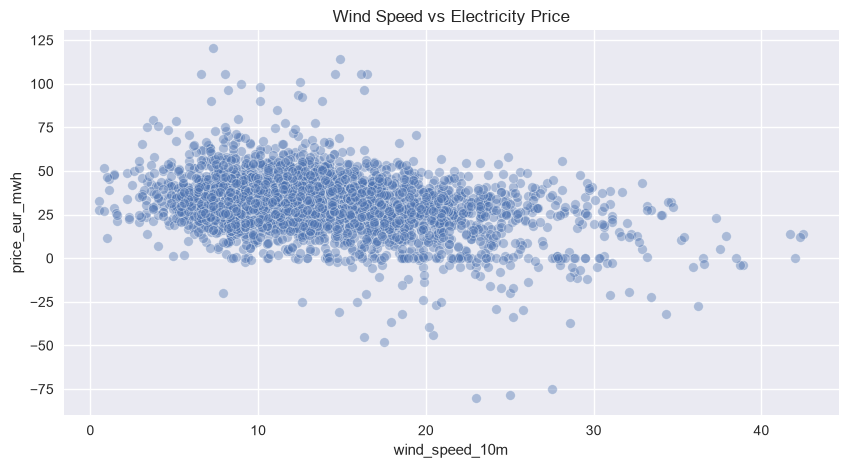

In [16]:
plt.figure(figsize=(10,5))


sns.scatterplot(
    data=df.sample(3000),
    x="wind_speed_10m",
    y="price_eur_mwh",
    alpha=0.4
)


plt.title(
    "Wind Speed vs Electricity Price"
)


plt.show()

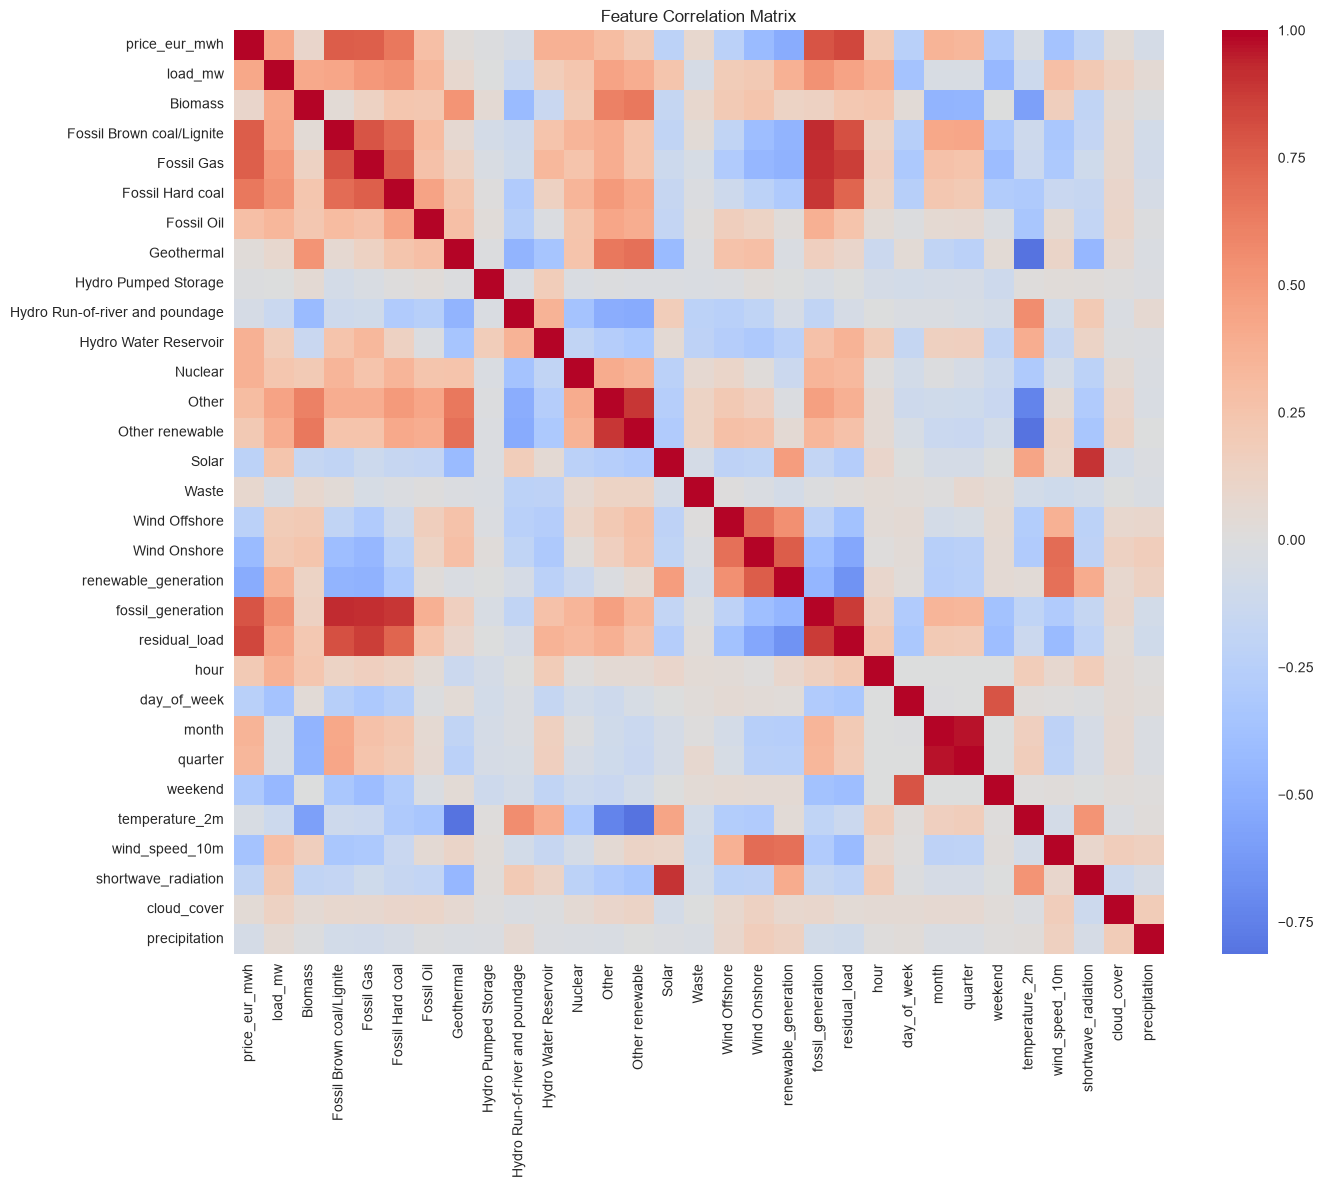

In [17]:
numeric_cols = df.select_dtypes(
    include=np.number
)


corr = numeric_cols.corr()


plt.figure(figsize=(15,12))


sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)


plt.title(
    "Feature Correlation Matrix"
)


plt.show()

In [18]:
price_corr = (
    corr["price_eur_mwh"]
    .sort_values(
        ascending=False
    )
)


price_corr

price_eur_mwh                      1.000000
residual_load                      0.843487
fossil_generation                  0.790165
Fossil Brown coal/Lignite          0.753740
Fossil Gas                         0.750899
Fossil Hard coal                   0.651711
load_mw                            0.425328
Hydro Water Reservoir              0.375474
Nuclear                            0.373004
month                              0.352519
quarter                            0.335372
Other                              0.304507
Fossil Oil                         0.281080
Other renewable                    0.216468
hour                               0.202378
Biomass                            0.099221
Waste                              0.083279
cloud_cover                        0.041254
Geothermal                         0.026632
Hydro Pumped Storage              -0.006291
temperature_2m                    -0.044804
Hydro Run-of-river and poundage   -0.057773
precipitation                   

In [19]:
eda_summary = {
    "observations": len(df),
    "features": df.shape[1]-1,
    "mean_price": df.price_eur_mwh.mean(),
    "max_price": df.price_eur_mwh.max(),
    "min_price": df.price_eur_mwh.min(),
    "negative_price_hours": len(negative_prices)
}


pd.DataFrame(
    [eda_summary]
).to_csv(
    "../data/eda_summary.csv",
    index=False
)


print("EDA summary saved")

EDA summary saved
